JAX devices: [CpuDevice(id=0)] | x64: False

L=8, beta=3.0, c0=0.125, init_scale=0.15, dt=0.005, t_final=0.3
n_links=16384 | n_vars=131072 | measure_every=5 | lanczos_k=25

Compiling (first call may take a bit)...
Compile warmup done in 22.67s

FLOW ENVELOPE TEST (logging)
t=0.000  lam_min=-0.355360 [UNSTABLE] | r_rms=0.15009 r_infL2=0.84709 r_infF=0.59898 | C2(r_infL2)=0.223 D1=0.189
t=0.025  lam_min=-0.286439 [UNSTABLE] | r_rms=0.13956 r_infL2=0.79359 r_infF=0.56116 | C2(r_infL2)=0.218 D1=0.173
t=0.050  lam_min=-0.235471 [UNSTABLE] | r_rms=0.13040 r_infL2=0.74563 r_infF=0.52724 | C2(r_infL2)=0.216 D1=0.161
t=0.075  lam_min=-0.190982 [UNSTABLE] | r_rms=0.12245 r_infL2=0.70272 r_infF=0.49690 | C2(r_infL2)=0.213 D1=0.150
t=0.100  lam_min=-0.152397 [UNSTABLE] | r_rms=0.11557 r_infL2=0.66440 r_infF=0.46980 | C2(r_infL2)=0.209 D1=0.139
t=0.125  lam_min=-0.115692 [UNSTABLE] | r_rms=0.10962 r_infL2=0.63020 r_infF=0.44562 | C2(r_infL2)=0.202 D1=0.127
t=0.150  lam_min=-0.085793 [UNSTABLE] | r_

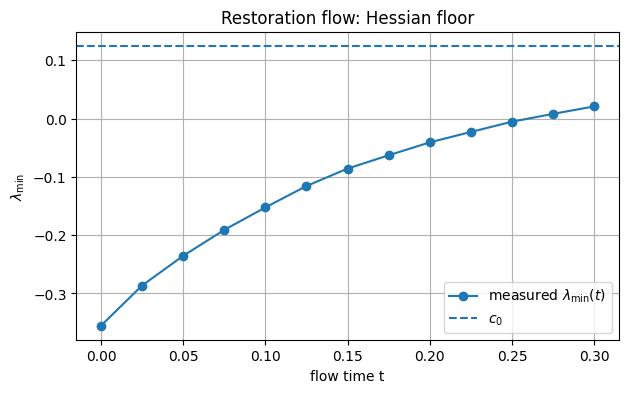

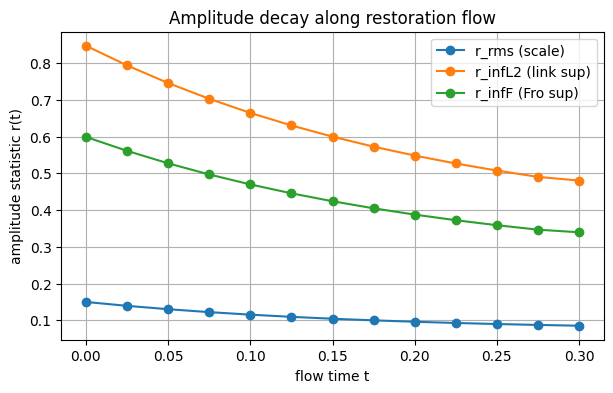

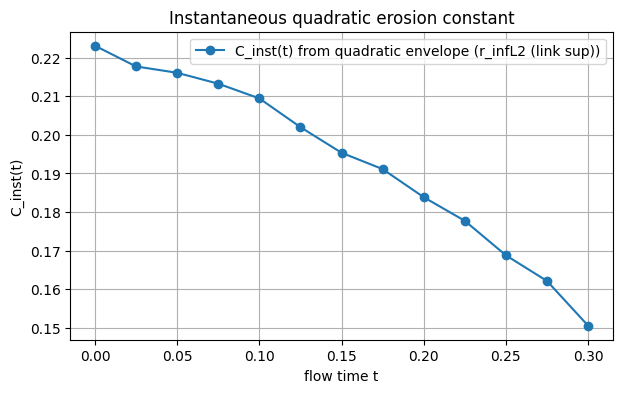

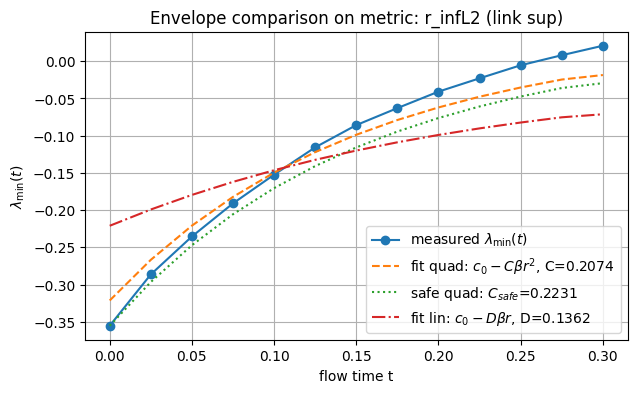


Done. (wall time depends on device / settings)
Last: t, lam_min, r_rms = 0.3 0.020855221897363663 0.08547014743089676


In [1]:
# ============================================================
# SU(3) restoration flow + Hessian-floor envelope logging
# One-cell Colab script (copy/paste and run)
# ============================================================

import os, time, math, warnings
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
warnings.filterwarnings("ignore", message="Casting complex values to real discards the imaginary part")

import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from jax import lax

# -----------------------
# User knobs
# -----------------------
L            = 8        # lattice linear size (CPU users: try L=4)
beta         = 3.0
c0           = 0.125    # Haar Hessian floor constant used in your runs
init_scale   = 0.15     # RMS per coefficient (your "scale" init)
dt           = 0.005
t_final      = 0.30
measure_dt   = 0.025    # log every 0.025 in flow-time (measure_every = measure_dt/dt must be integer)
lanczos_k    = 25       # Lanczos steps for lambda_min estimate (20-30 typical tradeoff)
seed         = 0

# Which r(t) do you want to be the "theorem r" for the envelope plots?
# Options: "r_rms", "r_infL2", "r_infF"
ENVELOPE_METRIC = "r_infL2"

assert abs(measure_dt/dt - round(measure_dt/dt)) < 1e-12
measure_every = int(round(measure_dt/dt))

print("JAX devices:", jax.devices(), "| x64:", jax.config.jax_enable_x64)

# -----------------------
# SU(3) generators (Gell-Mann)
# We use T_a = (i/2) * lambda_a (anti-Hermitian)
# With this normalization: Tr(A^† A) = (1/2) ||a||_2^2 for A = sum a_a T_a.
# -----------------------
def _gell_mann():
    z = 0.0 + 0.0j
    lam = []
    lam.append(jnp.array([[0,1,0],[1,0,0],[0,0,0]], dtype=jnp.complex64))                              # λ1
    lam.append(jnp.array([[0,-1j,0],[1j,0,0],[0,0,0]], dtype=jnp.complex64))                            # λ2
    lam.append(jnp.array([[1,0,0],[0,-1,0],[0,0,0]], dtype=jnp.complex64))                              # λ3
    lam.append(jnp.array([[0,0,1],[0,0,0],[1,0,0]], dtype=jnp.complex64))                               # λ4
    lam.append(jnp.array([[0,0,-1j],[0,0,0],[1j,0,0]], dtype=jnp.complex64))                            # λ5
    lam.append(jnp.array([[0,0,0],[0,0,1],[0,1,0]], dtype=jnp.complex64))                               # λ6
    lam.append(jnp.array([[0,0,0],[0,0,-1j],[0,1j,0]], dtype=jnp.complex64))                            # λ7
    lam.append((1/jnp.sqrt(3))*jnp.array([[1,0,0],[0,1,0],[0,0,-2]], dtype=jnp.complex64))              # λ8
    return jnp.stack(lam, axis=0)

LAM = _gell_mann()
T   = (0.5j) * LAM  # (8,3,3) anti-Hermitian generators

def su3_alg_from_vec(a8):
    # a8: (...,8) real
    return jnp.tensordot(a8, T, axes=([a8.ndim-1],[0]))  # (...,3,3) complex

def su3_exp_pade22(A):
    # [2/2] Padé approximant: exp(A) ~ (I + A/2 + A^2/12) (I - A/2 + A^2/12)^{-1}
    I  = jnp.eye(3, dtype=A.dtype)
    A2 = A @ A
    num = I + 0.5*A + (1.0/12.0)*A2
    den = I - 0.5*A + (1.0/12.0)*A2
    return jnp.linalg.solve(den, num)

def dagger(U):
    return jnp.swapaxes(U.conj(), -1, -2)

# -----------------------
# Lattice utilities
# theta is a flat real vector of length (L^4 * 4 * 8)
# -----------------------
n_sites = L**4
n_links = n_sites * 4
n_vars  = n_links * 8

def theta_to_links(theta):
    # returns U with shape (L,L,L,L,4,3,3)
    a = theta.reshape((L,L,L,L,4,8))
    a_flat = a.reshape((-1,8))
    A_flat = jax.vmap(su3_alg_from_vec)(a_flat)
    U_flat = jax.vmap(su3_exp_pade22)(A_flat)
    return U_flat.reshape((L,L,L,L,4,3,3))

def wilson_plaquette_sum(U):
    # Wilson action (without beta): sum_{plaquettes} (1 - Re Tr P / 3)
    S = 0.0
    # axes 0..3 correspond to x0..x3
    for mu in range(4):
        Umu = U[..., mu, :, :]
        for nu in range(mu+1, 4):
            Unu = U[..., nu, :, :]
            # shifts: value at x uses link at (x + direction)
            Unu_mu = jnp.roll(Unu, shift=-1, axis=mu)  # Unu(x+mu)
            Umu_nu = jnp.roll(Umu, shift=-1, axis=nu)  # Umu(x+nu)

            P = Umu @ Unu_mu @ dagger(Umu_nu) @ dagger(Unu)
            trP = jnp.real(jnp.trace(P, axis1=-2, axis2=-1))
            S = S + jnp.sum(1.0 - trP/3.0)
    return S

def total_action(theta):
    # S(theta) = beta * S_W + S_Haar, where S_Haar = (c0/2) * ||theta||^2
    U = theta_to_links(theta)
    SW = wilson_plaquette_sum(U)
    SH = 0.5 * c0 * jnp.sum(theta*theta)
    return beta*SW + SH

# JIT the expensive pieces
total_action_jit = jax.jit(total_action)
grad_action      = jax.jit(jax.grad(total_action))

@jax.jit
def flow_step(theta):
    return theta - dt * grad_action(theta)

@jax.jit
def hvp(theta, v):
    # Hessian-vector product via JVP of grad
    return jax.jvp(grad_action, (theta,), (v,))[1]

@jax.jit
def lanczos_min_eig(theta, key):
    # Estimate min eigenvalue of Hessian using m-step Lanczos
    v0 = jax.random.normal(key, (theta.shape[0],), dtype=theta.dtype)
    v0 = v0 / (jnp.linalg.norm(v0) + 1e-12)
    v_prev = jnp.zeros_like(v0)
    beta_prev = jnp.array(0.0, dtype=theta.dtype)

    def body(carry, _):
        v, v_prev, beta_prev = carry
        w = hvp(theta, v) - beta_prev * v_prev
        alpha = jnp.vdot(v, w).real
        w = w - alpha * v
        beta_new = jnp.linalg.norm(w)
        v_new = jnp.where(beta_new > 1e-12, w / beta_new, jnp.zeros_like(w))
        return (v_new, v, beta_new), (alpha, beta_new)

    (_, _, _), (alphas, betas) = lax.scan(body, (v0, v_prev, beta_prev), xs=None, length=lanczos_k)
    # Tridiagonal T: diag(alphas) + offdiag(betas[:-1])
    off = betas[:-1]
    Tmat = jnp.diag(alphas) + jnp.diag(off, 1) + jnp.diag(off, -1)
    evals = jnp.linalg.eigvalsh(Tmat)
    return evals[0]

def metrics(theta_np_or_jnp):
    th = jnp.asarray(theta_np_or_jnp)
    a = th.reshape((-1,8))
    # scale RMS across all link-coefficients (matches your init_scale convention)
    r_rms = jnp.sqrt(jnp.mean(a*a))
    # link-sup of coefficient L2 norm
    link_l2 = jnp.sqrt(jnp.sum(a*a, axis=-1))
    r_infL2 = jnp.max(link_l2)
    # link-sup Frobenius norm of the su(3) matrix A (for our normalization: r_infF = r_infL2/sqrt(2))
    r_infF = r_infL2 / jnp.sqrt(2.0)
    return r_rms, r_infL2, r_infF

def fit_envelopes(ts, lam, r, label):
    # y := (c0 - lam)/beta  so model is y ≈ C r^2 or y ≈ D r
    ts = np.asarray(ts)
    lam = np.asarray(lam)
    r = np.asarray(r)
    y = (c0 - lam) / beta

    r2 = r**2
    eps = 1e-12

    # Least-squares slope through origin: y ~ C r^2
    C_hat = float(np.dot(r2, y) / (np.dot(r2, r2) + eps))
    yC = C_hat * r2
    R2_C = 1.0 - float(np.sum((y - yC)**2) / (np.sum((y - y.mean())**2) + eps))

    # Least-squares slope through origin: y ~ D r
    D_hat = float(np.dot(r, y) / (np.dot(r, r) + eps))
    yD = D_hat * r
    R2_D = 1.0 - float(np.sum((y - yD)**2) / (np.sum((y - y.mean())**2) + eps))

    # Instantaneous constants
    C_inst = y / (r2 + eps)
    D_inst = y / (r + eps)

    # Tail stabilization: use second half of times
    mask_tail = ts >= 0.5*ts.max()
    def med_mad(x):
        x = np.asarray(x)[mask_tail]
        med = float(np.median(x))
        mad = float(np.median(np.abs(x - med)))
        return med, mad

    C_med, C_mad = med_mad(C_inst)
    D_med, D_mad = med_mad(D_inst)

    C_safe = float(np.max(C_inst))

    print("\n==============================")
    print(f"Metric: {label}")
    print(f"Quadratic fit: y~C r^2  => C_hat={C_hat:.6g},  R^2={R2_C:.4f},  tail median±MAD={C_med:.6g}±{C_mad:.3g}")
    print(f"Linear fit:    y~D r    => D_hat={D_hat:.6g},  R^2={R2_D:.4f},  tail median±MAD={D_med:.6g}±{D_mad:.3g}")
    print(f"Inequality-safe C_safe = max_t C_inst(t) ≈ {C_safe:.6g}")

    return dict(C_hat=C_hat, D_hat=D_hat, C_inst=C_inst, D_inst=D_inst, R2_C=R2_C, R2_D=R2_D, C_safe=C_safe)

def fit_gamma(ts, r, label):
    ts = np.asarray(ts)
    r = np.asarray(r)
    mask = ts >= 0.5*ts.max()
    coeff = np.polyfit(ts[mask], np.log(r[mask] + 1e-12), 1)
    gamma = -float(coeff[0])
    print(f"gamma_{label:8s} ~ {gamma:.6g}  (log-linear fit on 2nd half)")
    return gamma

# -----------------------
# Run
# -----------------------
key = jax.random.PRNGKey(seed)
theta = (init_scale * jax.random.normal(key, (n_vars,), dtype=jnp.float32))

print(f"\nL={L}, beta={beta}, c0={c0}, init_scale={init_scale}, dt={dt}, t_final={t_final}")
print(f"n_links={n_links} | n_vars={n_vars} | measure_every={measure_every} | lanczos_k={lanczos_k}")

# Warmup compile
print("\nCompiling (first call may take a bit)...")
t0 = time.time()
_ = total_action_jit(theta).block_until_ready()
_ = grad_action(theta).block_until_ready()
_ = lanczos_min_eig(theta, jax.random.PRNGKey(123)).block_until_ready()
print(f"Compile warmup done in {time.time()-t0:.2f}s")

ts = []
lam_list = []
r_rms_list = []
r_infL2_list = []
r_infF_list = []

n_steps = int(round(t_final/dt))
print("\nFLOW ENVELOPE TEST (logging)")
for step in range(n_steps + 1):
    t = step * dt
    if step % measure_every == 0:
        # Fresh Lanczos seed each measurement (deterministic)
        key_meas = jax.random.PRNGKey(10_000 + step)
        lam = float(lanczos_min_eig(theta, key_meas))
        r_rms, r_infL2, r_infF = metrics(theta)
        r_rms = float(r_rms); r_infL2 = float(r_infL2); r_infF = float(r_infF)

        ts.append(t)
        lam_list.append(lam)
        r_rms_list.append(r_rms)
        r_infL2_list.append(r_infL2)
        r_infF_list.append(r_infF)

        # Instantaneous constants for your preferred metric (printed live)
        if ENVELOPE_METRIC == "r_rms":
            rr = r_rms
        elif ENVELOPE_METRIC == "r_infL2":
            rr = r_infL2
        else:
            rr = r_infF

        C2 = (c0 - lam) / (beta * (rr**2 + 1e-12))
        D1 = (c0 - lam) / (beta * (rr + 1e-12))
        status = "RESTORED" if lam > 0 else "UNSTABLE"
        print(f"t={t:0.3f}  lam_min={lam:+0.6f} [{status}] | r_rms={r_rms:0.5f} r_infL2={r_infL2:0.5f} r_infF={r_infF:0.5f} | C2({ENVELOPE_METRIC})={C2:0.3f} D1={D1:0.3f}")

    if step < n_steps:
        theta = flow_step(theta)

# -----------------------
# Fit and plot
# -----------------------
ts_np = np.array(ts)
lam_np = np.array(lam_list)
r_rms_np = np.array(r_rms_list)
r_infL2_np = np.array(r_infL2_list)
r_infF_np = np.array(r_infF_list)

# Fit per-metric envelopes
fit_rms   = fit_envelopes(ts_np, lam_np, r_rms_np,   "r_rms (scale)")
fit_inf2  = fit_envelopes(ts_np, lam_np, r_infL2_np, "r_infL2 (link sup)")
fit_infF  = fit_envelopes(ts_np, lam_np, r_infF_np,  "r_infF (Fro sup)")

# Contraction rates
print("\n=== Rough contraction rates (2nd half log-linear fit) ===")
_ = fit_gamma(ts_np, r_rms_np,  "rms")
_ = fit_gamma(ts_np, r_infL2_np,"infL2")
_ = fit_gamma(ts_np, r_infF_np, "infF")

# Choose metric for the envelope overlay plot
if ENVELOPE_METRIC == "r_rms":
    r_plot = r_rms_np
    fit_plot = fit_rms
    metric_label = "r_rms (scale)"
elif ENVELOPE_METRIC == "r_infL2":
    r_plot = r_infL2_np
    fit_plot = fit_inf2
    metric_label = "r_infL2 (link sup)"
else:
    r_plot = r_infF_np
    fit_plot = fit_infF
    metric_label = "r_infF (Fro sup)"

C_hat = fit_plot["C_hat"]
D_hat = fit_plot["D_hat"]
C_safe = fit_plot["C_safe"]

env_quad = c0 - beta * C_hat * (r_plot**2)
env_lin  = c0 - beta * D_hat * (r_plot)
env_safe = c0 - beta * C_safe * (r_plot**2)

plt.figure(figsize=(7,4))
plt.plot(ts_np, lam_np, "o-", label=r"measured $\lambda_{\min}(t)$")
plt.axhline(c0, linestyle="--", label=r"$c_0$")
plt.title("Restoration flow: Hessian floor")
plt.xlabel("flow time t"); plt.ylabel(r"$\lambda_{\min}$")
plt.grid(True); plt.legend(); plt.show()

plt.figure(figsize=(7,4))
plt.plot(ts_np, r_rms_np,  "o-", label="r_rms (scale)")
plt.plot(ts_np, r_infL2_np,"o-", label="r_infL2 (link sup)")
plt.plot(ts_np, r_infF_np, "o-", label="r_infF (Fro sup)")
plt.title("Amplitude decay along restoration flow")
plt.xlabel("flow time t"); plt.ylabel("amplitude statistic r(t)")
plt.grid(True); plt.legend(); plt.show()

plt.figure(figsize=(7,4))
C_inst_plot = (c0 - lam_np) / (beta * (r_plot**2 + 1e-12))
plt.plot(ts_np, C_inst_plot, "o-", label=f"C_inst(t) from quadratic envelope ({metric_label})")
plt.title("Instantaneous quadratic erosion constant")
plt.xlabel("flow time t"); plt.ylabel("C_inst(t)")
plt.grid(True); plt.legend(); plt.show()

plt.figure(figsize=(7,4))
plt.plot(ts_np, lam_np, "o-", label=r"measured $\lambda_{\min}(t)$")
plt.plot(ts_np, env_quad, "--", label=fr"fit quad: $c_0 - C\beta r^2$, C={C_hat:.4g}")
plt.plot(ts_np, env_safe, ":",  label=fr"safe quad: $C_{{safe}}$={C_safe:.4g}")
plt.plot(ts_np, env_lin,  "-.", label=fr"fit lin: $c_0 - D\beta r$, D={D_hat:.4g}")
plt.title(f"Envelope comparison on metric: {metric_label}")
plt.xlabel("flow time t"); plt.ylabel(r"$\lambda_{\min}(t)$")
plt.grid(True); plt.legend(); plt.show()

print("\nDone. (wall time depends on device / settings)")
print("Last:", "t, lam_min, r_rms =", ts_np[-1], lam_np[-1], r_rms_np[-1])